In [3]:
import numpy as np

# 1. 生成 7天 * 3种产品 的随机销售量 (10到50之间)
# randint(low, high, size)
sales_counts = np.random.randint(10, 51, size=(7, 3))
print("销售量矩阵：\n", sales_counts)

# 2. 定义单价数组 (拿铁, 美式, 卡布奇诺)
prices = np.array([30, 25, 35])

# 3. 计算每天每种产品的总营业额 (利用NumPy的广播机制)
# 这里的矩阵每行都会乘以 prices 对应的元素
daily_revenue_matrix = sales_counts * prices
print("\n每日各项产品营业额：\n", daily_revenue_matrix)

销售量矩阵：
 [[45 45 15]
 [23 12 31]
 [13 24 44]
 [32 42 45]
 [29 21 26]
 [30 40 23]
 [12 46 17]]

每日各项产品营业额：
 [[1350 1125  525]
 [ 690  300 1085]
 [ 390  600 1540]
 [ 960 1050 1575]
 [ 870  525  910]
 [ 900 1000  805]
 [ 360 1150  595]]


In [4]:
import pandas as pd

# 1. 创建 DataFrame
products = ['拿铁', '美式', '卡布奇诺']
dates = ['周一', '周二', '周三', '周四', '周五', '周六', '周日']
df = pd.DataFrame(daily_revenue_matrix, index=dates, columns=products)

# 2. 模拟数据缺失：将周三的美式咖啡销售额设为缺失(NaN)
df.loc['周三', '美式'] = np.nan
print("初始报表（含缺失值）：\n", df)

# 3. 进阶练习：填充缺失值（用周二和周四的平均值）
avg_val = (df.loc['周二', '美式'] + df.loc['周四', '美式']) / 2
df.loc['周三', '美式'] = avg_val

# 4. 数据统计
df['Daily_Total'] = df.sum(axis=1) # 增加一行：每日总额
weekly_total = df.sum(axis=0)     # 计算每种产品一周总销量（额）

print("\n填充并统计后的报表：\n", df)
print("\n一周各产品总营业额：\n", weekly_total)

初始报表（含缺失值）：
       拿铁      美式  卡布奇诺
周一  1350  1125.0   525
周二   690   300.0  1085
周三   390     NaN  1540
周四   960  1050.0  1575
周五   870   525.0   910
周六   900  1000.0   805
周日   360  1150.0   595

填充并统计后的报表：
       拿铁      美式  卡布奇诺  Daily_Total
周一  1350  1125.0   525       3000.0
周二   690   300.0  1085       2075.0
周三   390   675.0  1540       2605.0
周四   960  1050.0  1575       3585.0
周五   870   525.0   910       2305.0
周六   900  1000.0   805       2705.0
周日   360  1150.0   595       2105.0

一周各产品总营业额：
 拿铁              5520.0
美式              5825.0
卡布奇诺            7035.0
Daily_Total    18380.0
dtype: float64


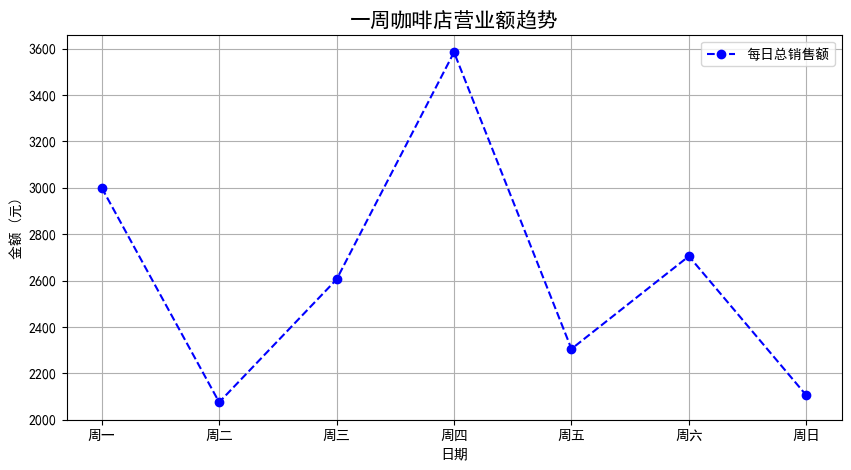

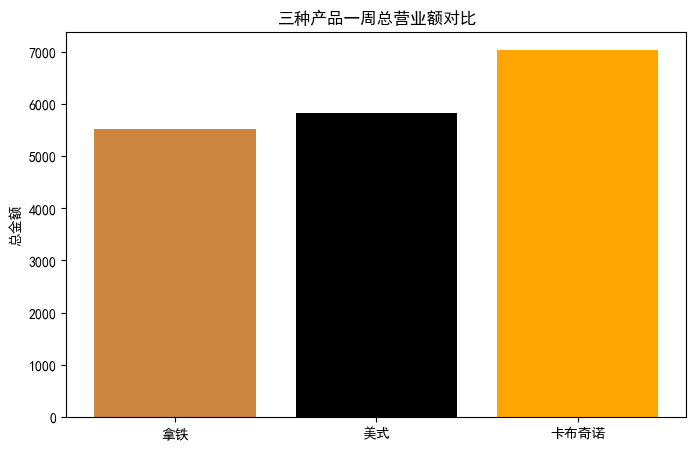

In [5]:
import matplotlib.pyplot as plt

# 解决中文显示问题（如果你是Windows/Mac，这几行很重要）
plt.rcParams['font.sans-serif'] = ['SimHei'] # 设置中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 1. 绘制折线图：7天总营业额变化
plt.figure(figsize=(10, 5)) # 设置画布大小
plt.plot(df.index, df['Daily_Total'], marker='o', color='blue', linestyle='--', label='每日总销售额')
plt.title('一周咖啡店营业额趋势', fontsize=15)
plt.xlabel('日期')
plt.ylabel('金额 (元)')
plt.grid(True) # 显示网格
plt.legend()
plt.show()

# 2. 绘制柱状图：各产品一周贡献对比
plt.figure(figsize=(8, 5))
# 我们排除掉 Daily_Total 这一列再画
weekly_total_products = weekly_total.drop('Daily_Total') 
plt.bar(weekly_total_products.index, weekly_total_products.values, color=['peru', 'black', 'orange'])
plt.title('三种产品一周总营业额对比')
plt.ylabel('总金额')
plt.show()